In [ ]:
# Library to suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Libraries to help with data visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Library to extract datetime features
import datetime as dt

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Uber.csv')

In [ ]:
# Copying data to another variable to avoid any changes to the original data
df = data.copy()

In [ ]:
# Looking at head (the first 5 observations)
df.head()

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
0,2015-01-01 01:00:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
1,2015-01-01 01:00:00,Brooklyn,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
2,2015-01-01 01:00:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
3,2015-01-01 01:00:00,Manhattan,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
4,2015-01-01 01:00:00,Queens,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y


In [ ]:
# Looking at tail (the last 5 observations)
df.tail()

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
29096,2015-06-30 23:00:00,EWR,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29097,2015-06-30 23:00:00,Manhattan,3828,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29098,2015-06-30 23:00:00,Queens,580,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29099,2015-06-30 23:00:00,Staten Island,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29100,2015-06-30 23:00:00,NaN,3,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N


In [ ]:
df.shape

(29101, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29101 entries, 0 to 29100
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   borough      29101 non-null  object 
 1   pickups      29101 non-null  int64  
 2   spd          29101 non-null  float64
 3   vsb          29101 non-null  float64
 4   temp         29101 non-null  float64
 5   dewp         29101 non-null  float64
 6   slp          29101 non-null  float64
 7   pcp01        29101 non-null  float64
 8   pcp06        29101 non-null  float64
 9   pcp24        29101 non-null  float64
 10  sd           29101 non-null  float64
 11  hday         29101 non-null  object 
 12  start_year   29101 non-null  int64  
 13  start_month  29101 non-null  object 
 14  start_hour   29101 non-null  int64  
 15  start_day    29101 non-null  int64  
 16  week_day     29101 non-null  object 
dtypes: float64(9), int64(4), object(4)
memory usage: 3.8+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pickups,29101.0,490.215903,995.649536,0.0,1.0,54.0,449.000000,7883.00
spd,29101.0,5.984924,3.699007,0.0,3.0,6.0,8.000000,21.00
vsb,29101.0,8.818125,2.442897,0.0,9.1,10.0,10.000000,10.00
temp,29101.0,47.669042,19.814969,2.0,32.0,46.0,64.500000,89.00
dewp,29101.0,30.823065,21.283444,-16.0,14.0,30.0,50.000000,73.00
slp,29101.0,1017.817938,7.768796,991.4,1012.5,1018.2,1022.900000,1043.40
pcp01,29101.0,0.003830,0.018933,0.0,0.0,0.0,0.000000,0.28
pcp06,29101.0,0.026129,0.093125,0.0,0.0,0.0,0.000000,1.24
pcp24,29101.0,0.090464,0.219402,0.0,0.0,0.0,0.050000,2.10
sd,29101.0,2.529169,4.520325,0.0,0.0,0.0,2.958333,19.00


* There is a significant discrepancy between the third quartile and the highest value for the number of pickups (pickups) and the snow depth (sd), indicating that these variables may have outliers to the right.
* The temperature has a broad range, showing that the data includes records from the winter as well as summer seasons.

In [ ]:
df.describe(exclude = 'number').T

,count,unique,top,freq
pickup_dt,29101,4343,2015-01-01 01:00:00,7
borough,26058,6,Bronx,4343
hday,29101,2,N,27980


**Observations:**

* The variable 'borough' has six unique categories. The category Bronx has occurred 4,343 times in the data.
* The variable 'hday' has 2 unique categories. The category N, i.e., not a holiday as occurred more often, which makes sense.

**Let's check the count of each unique category in each of the categorical variables.**

In [ ]:
# Making a list of all categorical variables
cat_col = ['borough', 'hday']

# Printing number of count of each unique value in each column
for column in cat_col:
    print(df[column].value_counts())

    print('-' * 50)

Bronx            4343
Brooklyn         4343
EWR              4343
Manhattan        4343
Queens           4343
Staten Island    4343
Unknown          3043
Name: borough, dtype: int64
--------------------------------------------------
N    27980
Y     1121
Name: hday, dtype: int64
--------------------------------------------------


In [ ]:
df["pickup_dt"]

0        2015-01-01 01:00:00
1        2015-01-01 01:00:00
2        2015-01-01 01:00:00
3        2015-01-01 01:00:00
4        2015-01-01 01:00:00
                ...         
29096    2015-06-30 23:00:00
29097    2015-06-30 23:00:00
29098    2015-06-30 23:00:00
29099    2015-06-30 23:00:00
29100    2015-06-30 23:00:00
Name: pickup_dt, Length: 29101, dtype: object

* The above output shows that the borough variable has an equal count for each category.

### **Extracting date parts from pickup date**

In [ ]:
# Converting pickup_dt datatype to datetime
df.pickup_dt = pd.to_datetime(df.pickup_dt)

# Extracting date parts from pickup_dt
df['start_year'] = df.pickup_dt.dt.year

df['start_month'] = df.pickup_dt.dt.month_name()

df['start_hour'] = df.pickup_dt.dt.hour

df['start_day'] = df.pickup_dt.dt.day

df['week_day'] = df.pickup_dt.dt.day_name()



In [ ]:
df
#Check the data parts

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday,start_year,start_month,start_hour,start_day,week_day
0,2015-01-01 01:00:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,2015,January,1,1,Thursday
1,2015-01-01 01:00:00,Brooklyn,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,2015,January,1,1,Thursday
2,2015-01-01 01:00:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,2015,January,1,1,Thursday
3,2015-01-01 01:00:00,Manhattan,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,2015,January,1,1,Thursday
4,2015-01-01 01:00:00,Queens,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,2015,January,1,1,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29096,2015-06-30 23:00:00,EWR,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N,2015,June,23,30,Tuesday
29097,2015-06-30 23:00:00,Manhattan,3828,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N,2015,June,23,30,Tuesday
29098,2015-06-30 23:00:00,Queens,580,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N,2015,June,23,30,Tuesday
29099,2015-06-30 23:00:00,Staten Island,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N,2015,June,23,30,Tuesday


In [ ]:
# Removing pickup_dt column as it will not be required for further analysis
df.drop('pickup_dt', axis = 1, inplace = True)
df = df.drop('pickup_dt', axis = 1)
""" df.drop('pickup_dt', axis = 1, inplace = True) or
df = df.drop('pickup_dt', axis = 1) can be used """

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29101 entries, 0 to 29100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   pickup_dt    29101 non-null  datetime64[ns]
 1   borough      26058 non-null  object        
 2   pickups      29101 non-null  int64         
 3   spd          29101 non-null  float64       
 4   vsb          29101 non-null  float64       
 5   temp         29101 non-null  float64       
 6   dewp         29101 non-null  float64       
 7   slp          29101 non-null  float64       
 8   pcp01        29101 non-null  float64       
 9   pcp06        29101 non-null  float64       
 10  pcp24        29101 non-null  float64       
 11  sd           29101 non-null  float64       
 12  hday         29101 non-null  object        
 13  start_year   29101 non-null  int64         
 14  start_month  29101 non-null  object        
 15  start_hour   29101 non-null  int64         
 16  star

### **Missing value treatment**

In [ ]:
# Checking missing values
df.isna().sum()
#Shows the number of missing values in columns

pickup_dt         0
borough        3043
pickups           0
spd               0
vsb               0
temp              0
dewp              0
slp               0
pcp01             0
pcp06             0
pcp24             0
sd                0
hday              0
start_year        0
start_month       0
start_hour        0
start_day         0
week_day          0
dtype: int64

In [ ]:
df.borough.unique() #Gives the unique values in borough column

array(['Bronx', 'Brooklyn', 'EWR', 'Manhattan', 'Queens', 'Staten Island',
       nan], dtype=object)

* There are 3043 missing values for the variable borough.
* Other variables have no missing values.

In [ ]:
# Checking the missing values further
df.borough.value_counts(normalize = True, dropna = False)*100
# How many values are there under each borough in percentage

Bronx            14.923886
Brooklyn         14.923886
EWR              14.923886
Manhattan        14.923886
Queens           14.923886
Staten Island    14.923886
NaN              10.456685
Name: borough, dtype: float64

* All the six categories have the same percentage, i.e., ~15%. There is no mode (or multiple modes) for this variable.
* The percentage of missing values is close to the percentage of observations from other boroughs.
* We can treat the missing values as a separate category for this variable.

In [ ]:
# Replacing NaN with Unknown
df['borough'].fillna('Unknown', inplace = True)

In [ ]:
df.borough.value_counts()

Bronx            4343
Brooklyn         4343
EWR              4343
Manhattan        4343
Queens           4343
Staten Island    4343
Unknown          3043
Name: borough, dtype: int64

In [ ]:
df.isnull().sum()

pickup_dt      0
borough        0
pickups        0
spd            0
vsb            0
temp           0
dewp           0
slp            0
pcp01          0
pcp06          0
pcp24          0
sd             0
hday           0
start_year     0
start_month    0
start_hour     0
start_day      0
week_day       0
dtype: int64

* Now, there are no missing values in the data.

## **Exploratory Data Analysis: Univariate**

**Let us explore the numerical variables first.**

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#figsize can specified or autocomputed
def histogram_boxplot(feature, figsize=(15, 10), bins="auto"):
    """ Boxplot and histogram combined
    feature: 1-d feature array
    figsize: size of fig (default (15, 10))
    bins: number of bins (default "auto")
    """
    f, (ax_box, ax_hist) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid
        sharex=True,  # The X-axis will be shared among all the subplots
        gridspec_kw={"height_ratios": (.25, .75)},
        figsize=figsize
    )

    # Creating the subplots
    # Boxplot will be created and the mean value of the column will be indicated using some symbol
    sns.boxplot(x=feature, ax=ax_box, showmeans=True, color='red')

    # For histogram #kde is computed value on histogram plots
    sns.histplot(x=feature, kde=False, ax=ax_hist, bins=bins)
    ax_hist.axvline(np.mean(feature), color='g', linestyle='--')      # Add mean to the histogram
    ax_hist.axvline(np.median(feature), color='black', linestyle='-') # Add median to the histogram

    plt.show()

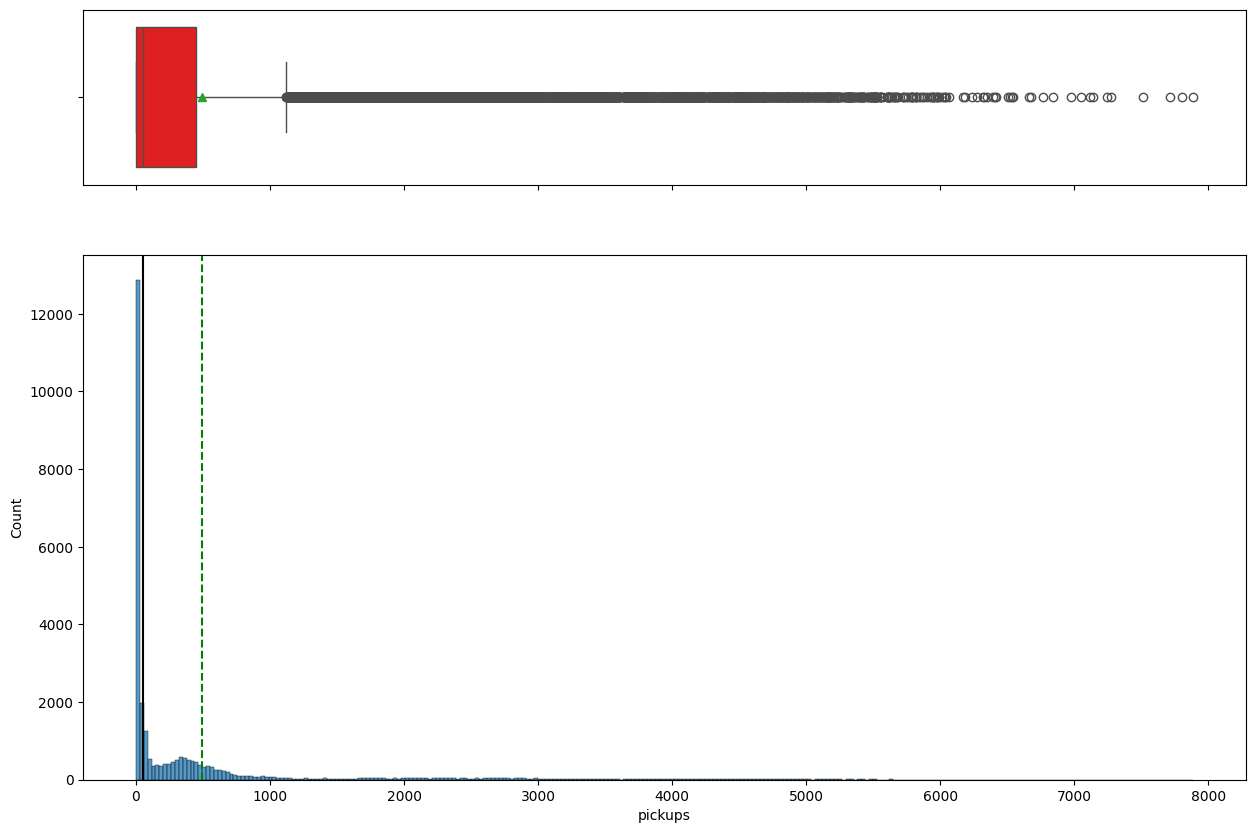

In [ ]:
plt.show(histogram_boxplot(df.pickups))

### **Observations on Pickups**

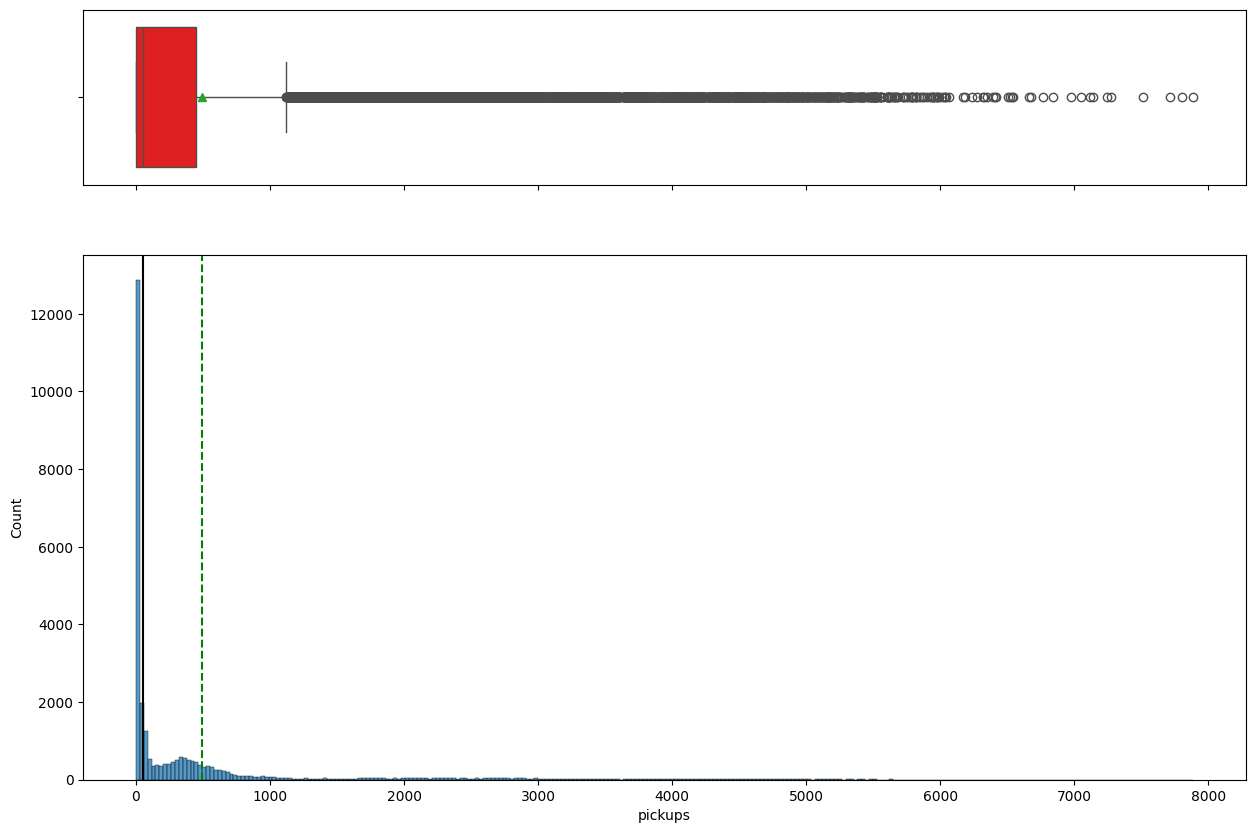

In [ ]:
histogram_boxplot(df.pickups)


**Observations:**
* The distribution of hourly pickups is highly right-skewed.
* The majority of the hourly pickups are close to 0.
* Median pickups are equal to 0, but the mean is ~500.
* There are a lot of outliers in this variable.
* While most hourly pickups are at the lower end, we have observations where hourly pickups went as high as 8000.

###  **Observations on Visibility**

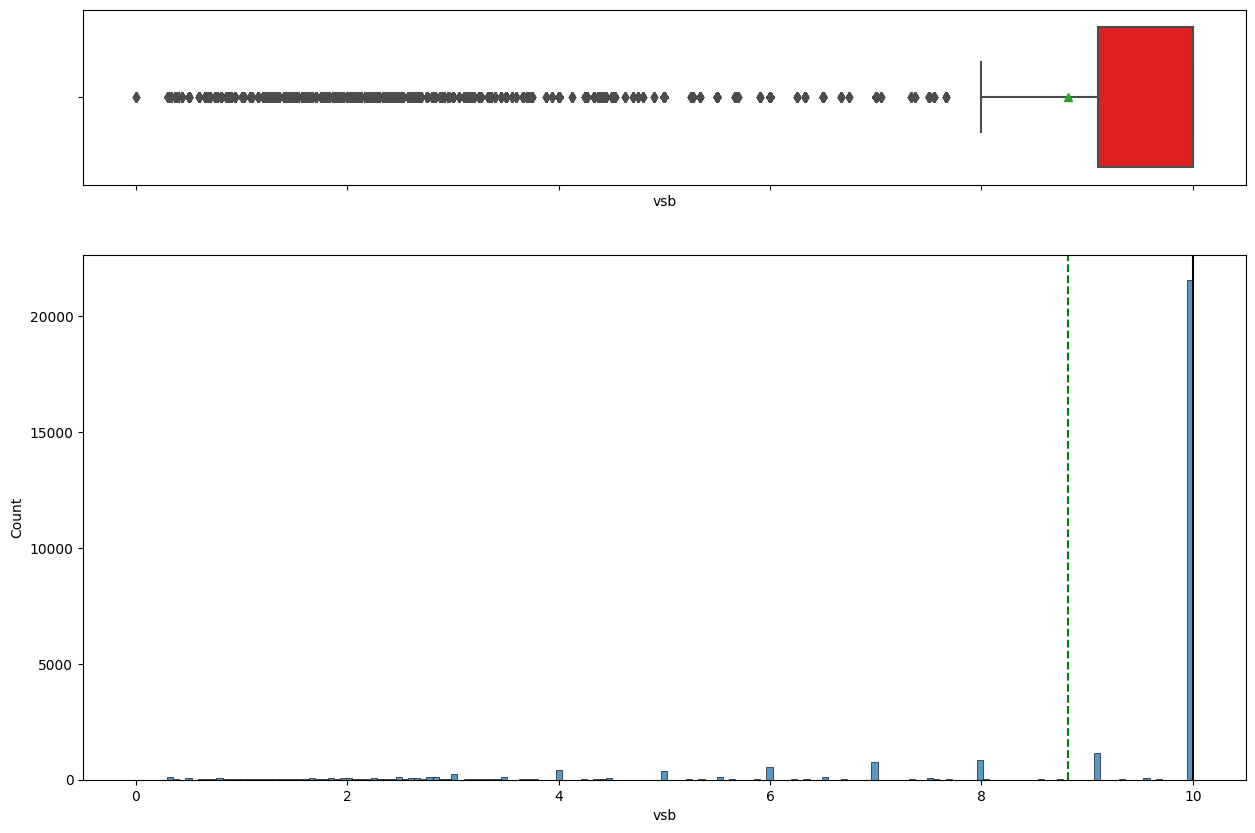

In [ ]:
histogram_boxplot(df.vsb)
#using variable vsb
#Visibility is low in some cases
#In most cases the visibility is good

**Observations:**
* The distribution of 'visibility' is left-skewed.
* Both the mean and the median are high, indicating that the visibility is good on most days.
* There are, however, outliers towards the left, indicating that visibility is extremely low on some days.
* It will be interesting to see how visibility affects the Uber pickup frequency.

### **Observations on Snow Depth**

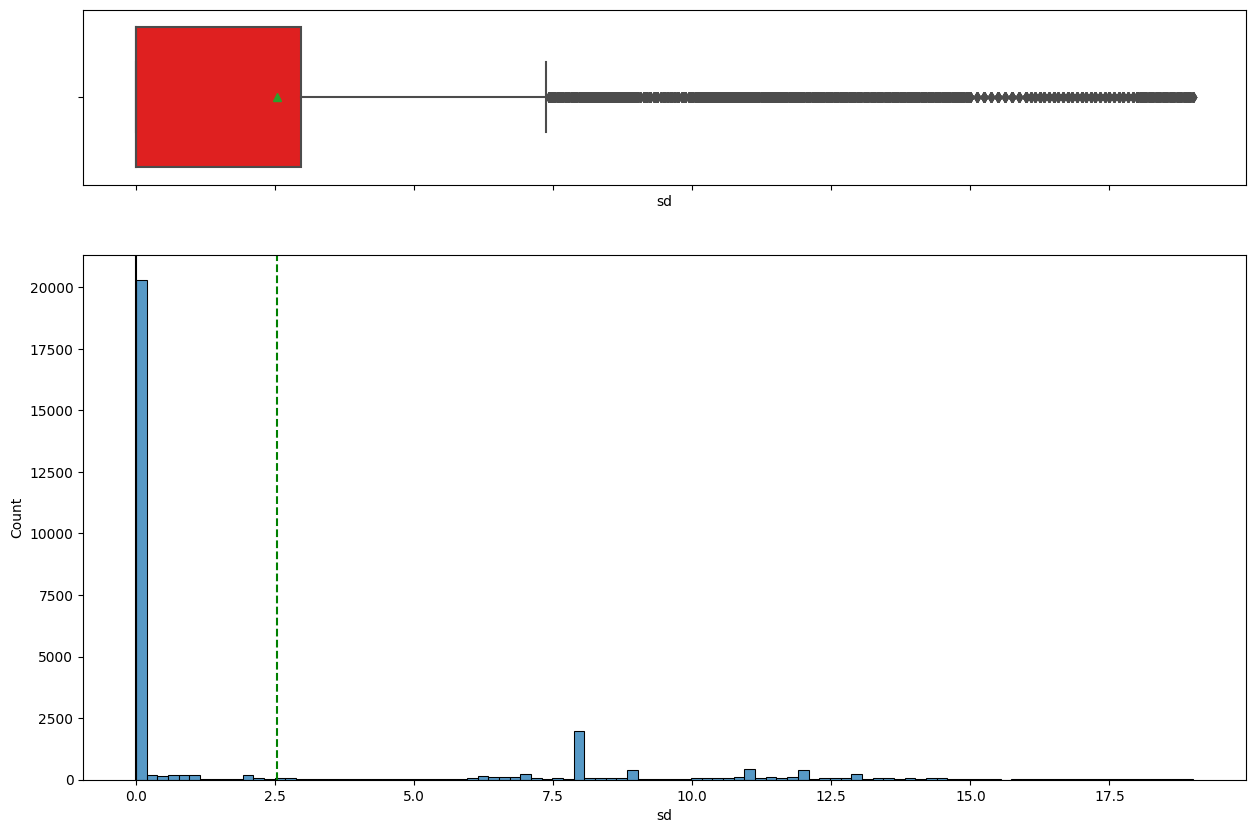

In [ ]:
histogram_boxplot(df.sd)

**Observations:**
* We observe that there is a snowfall in the period that we are analyzing.
* There are outliers in this variable.
* We will have to see how snowfall affects pickups. We know that very few people are likely to get out if it is snowing heavily, so our pickups would likely decrease when it snows.

**Now, let's explore the categorical variables.**

In [ ]:
def bar_perc(data, z):
    total = len(data[z]) # Length of the column
    plt.figure(figsize = (15, 5))

    # Convert the column to a categorical data type
    data[z] = data[z].astype('category')

    ax = sns.countplot(x=z, data=data, palette='Paired', order=data[z].value_counts().index)

    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total) # Percentage of each class
        x = p.get_x() + p.get_width() / 2 - 0.05                    # Width of the plot
        y = p.get_y() + p.get_height()                              # Height of the plot
        ax.annotate(percentage, (x, y), size = 12)                  # Annotate the percentage

    plt.show()                                                      # Display the plot

### **Observations on holiday**

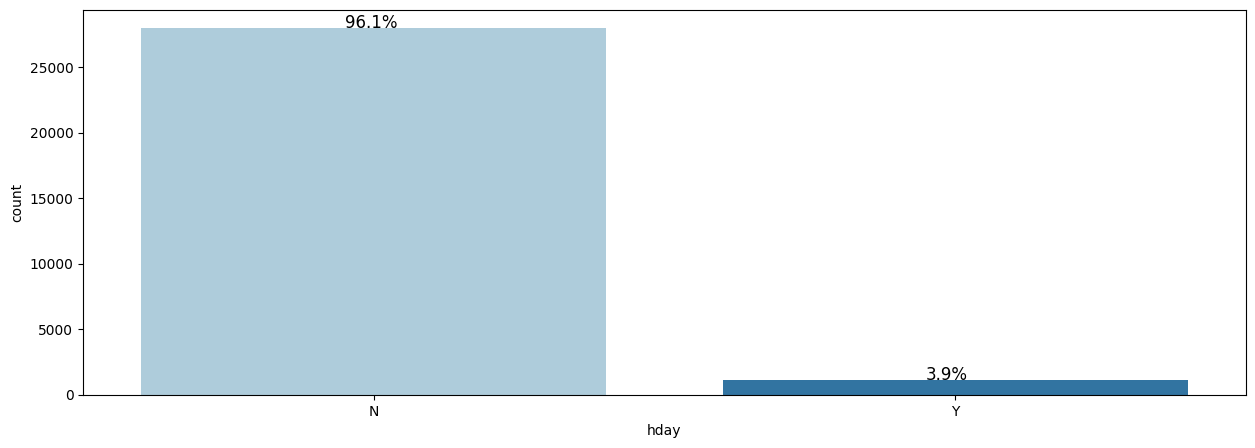

In [ ]:
bar_perc(df, 'hday')
#Annotation is used to add notes and comments in the plots

**Observation:**

* Only 3.9% of days were holidays in the period that we are analyzing.

### **Observations on borough**

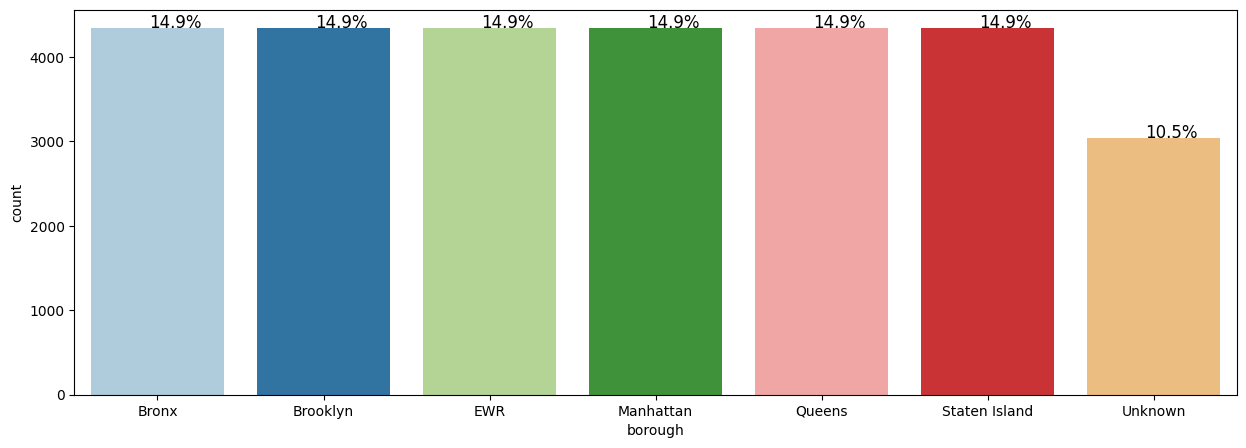

In [ ]:
bar_perc(df, 'borough')

**Observation:**

* The observations are uniformly distributed across the boroughs except for the observations that had NaN values and were attributed to the Unknown borough.

## **Exploratory Data Analysis: Multivariate**

**Let's plot multivariate charts between variables to understand their interaction with each other.**

### Correlation

<Axes: >

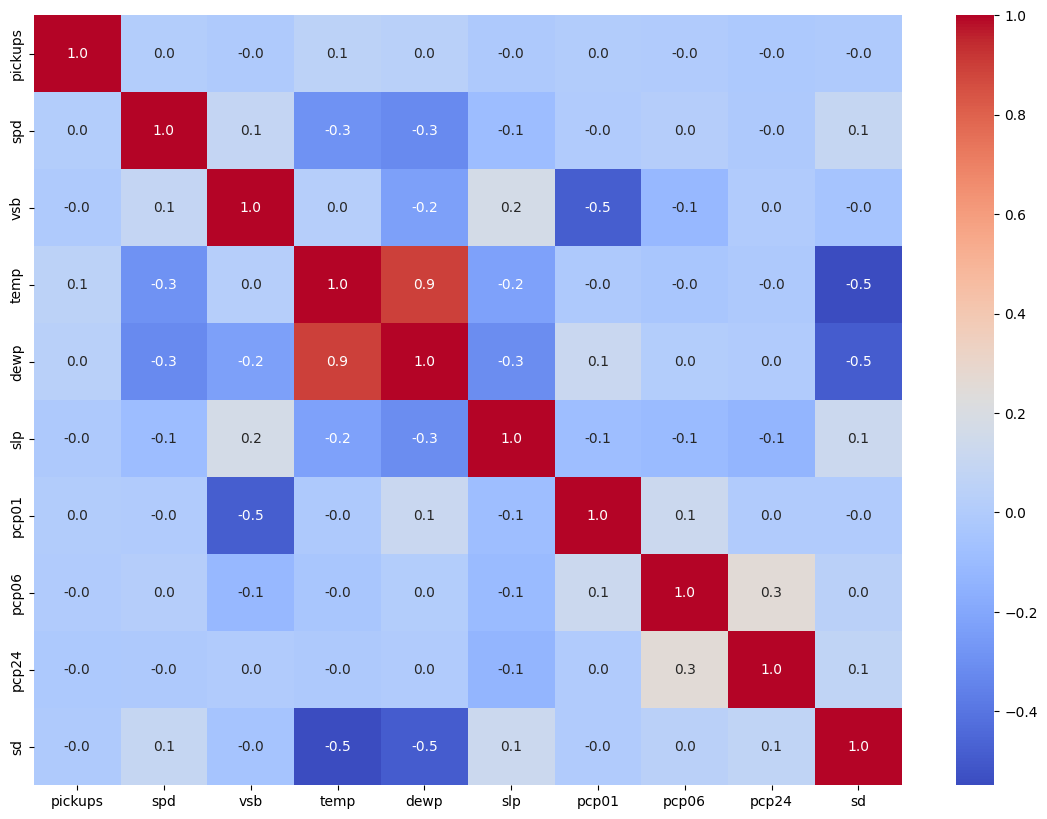

In [ ]:
# Check for correlation among numerical variables
num_var = ['pickups', 'spd', 'vsb', 'temp', 'dewp', 'slp', 'pcp01', 'pcp06', 'pcp24', 'sd']
corr = df[num_var].corr()

# Plot the heatmap
plt.figure(figsize = (14, 10))
sns.heatmap(corr, annot = True, cmap = 'coolwarm',
        fmt = ".1f",
        xticklabels = corr.columns,
        yticklabels = corr.columns)
#dewpoint and temp are higly correlated
#pcp01 and vsb correlation is high(-0.5)s

**Observations:**

* Dew point is an indication of humidity, which is correlated with temperature and the same thing can be observed in the heatmap as well. Temperature shows a high correlation with dew point.
* Visibility is negatively correlated with precipitation. If the rains are high during the hour, visibility is low. This is aligned with our intuitive understanding.
* Snow depth, of course, would be negatively correlated with the temperature.
* The wind speed and the sea level pressure are negatively correlated with the temperature.
* It is important to note that correlation does not imply causation.
* There does not seem to be a strong relationship between the number of pickups and weather stats.

## **Relationship between pickups and time based variables**

### **Pickups across Months**

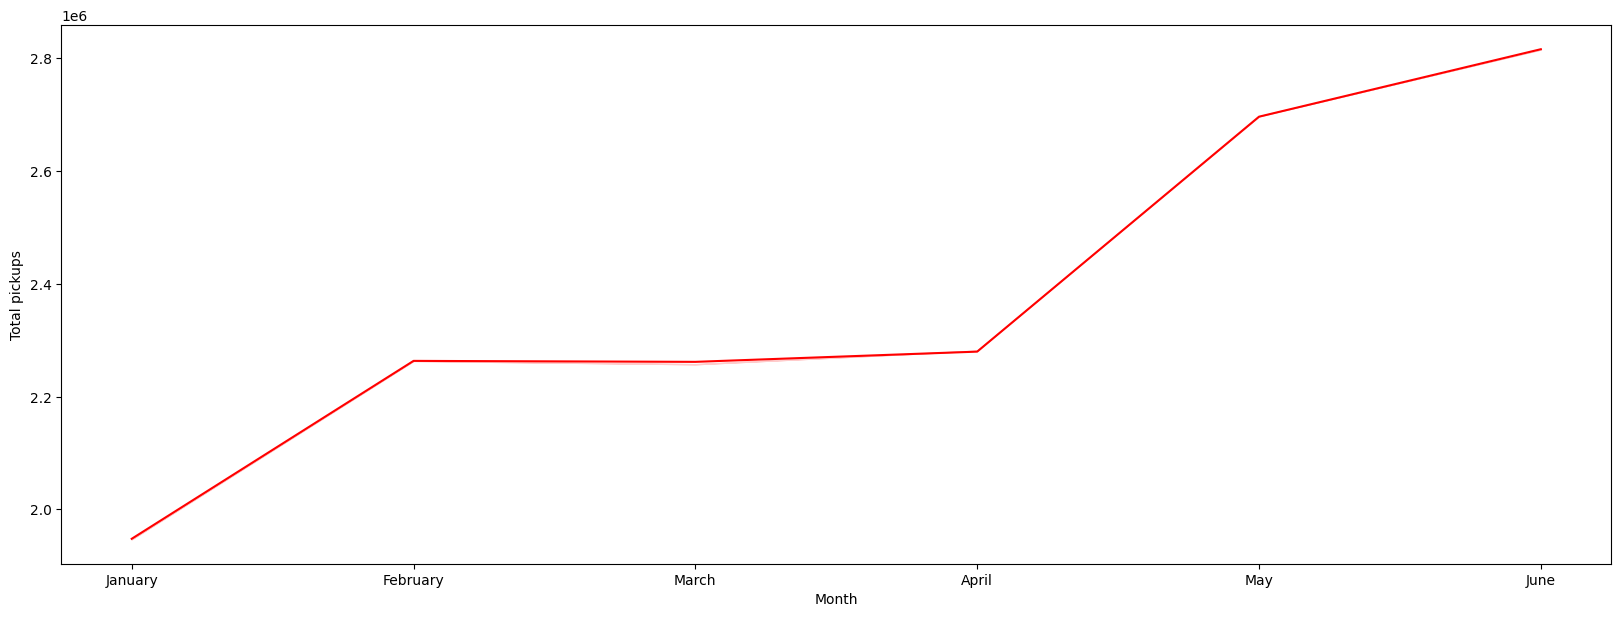

In [ ]:
cats = df.start_month.unique().tolist()
df.start_month = pd.Categorical(df.start_month, ordered = True, categories = cats)
plt.figure(figsize = (20, 7))
sns.lineplot(x = "start_month", y = "pickups", data = df, ci = 0, color = "RED", estimator = 'sum')
plt.ylabel('Total pickups')
plt.xlabel('Month')
plt.show()
#hire more drivers between May and June

**Observations:**
* There is a clear increasing trend in monthly bookings.
* Bookings in June are almost 1.5 times that of Jan.

### **Pickups vs Days of the Month**

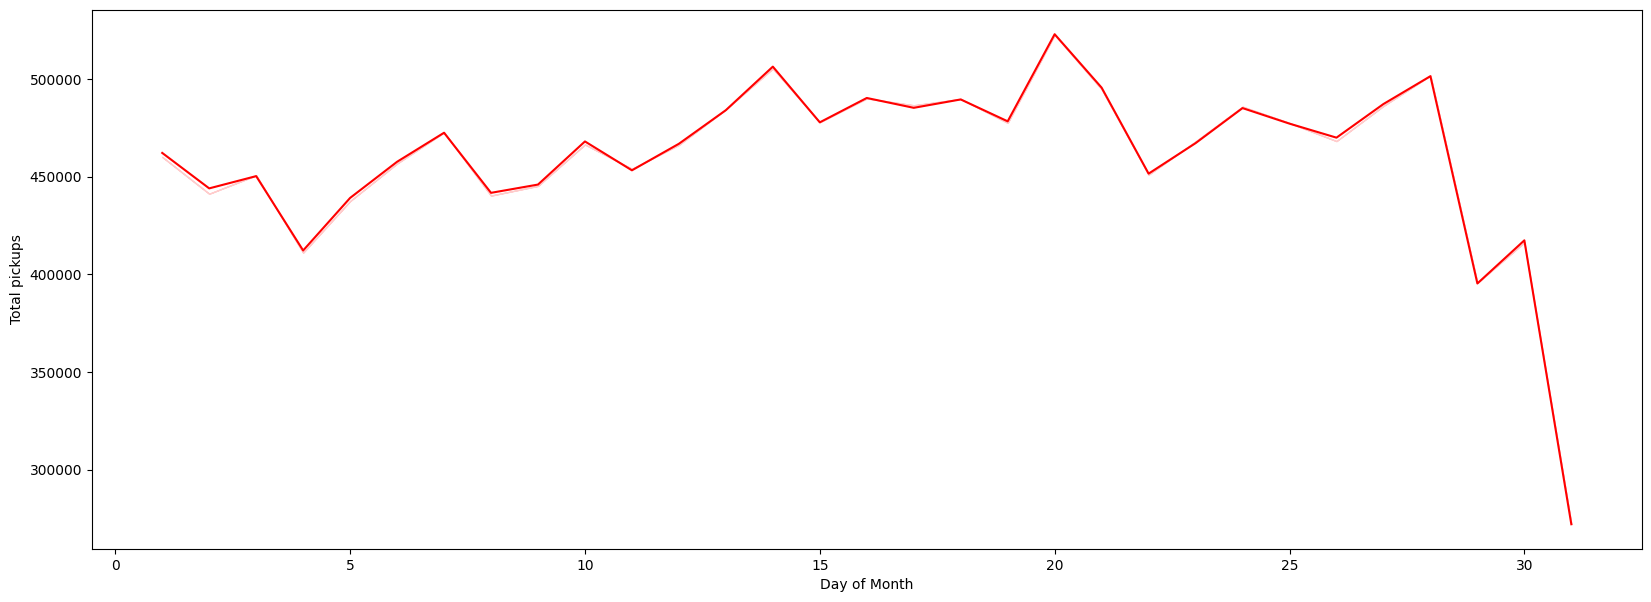

In [ ]:
plt.figure(figsize = (20, 7))
sns.lineplot(x = "start_day", y = "pickups", estimator = 'sum', ci = 0, data = df, color = "RED")
plt.ylabel('Total pickups')
plt.xlabel('Day of Month')
plt.show()
# not a significant variation

**Observations:**
* Number of pickups are low towards the end of the month (29th - 31st).
* Number of pickups for 31 might be low because not all months have the 31st day.
* There is a peak in the bookings around the 20th day of the month.

### **Pickups across Weekdays**

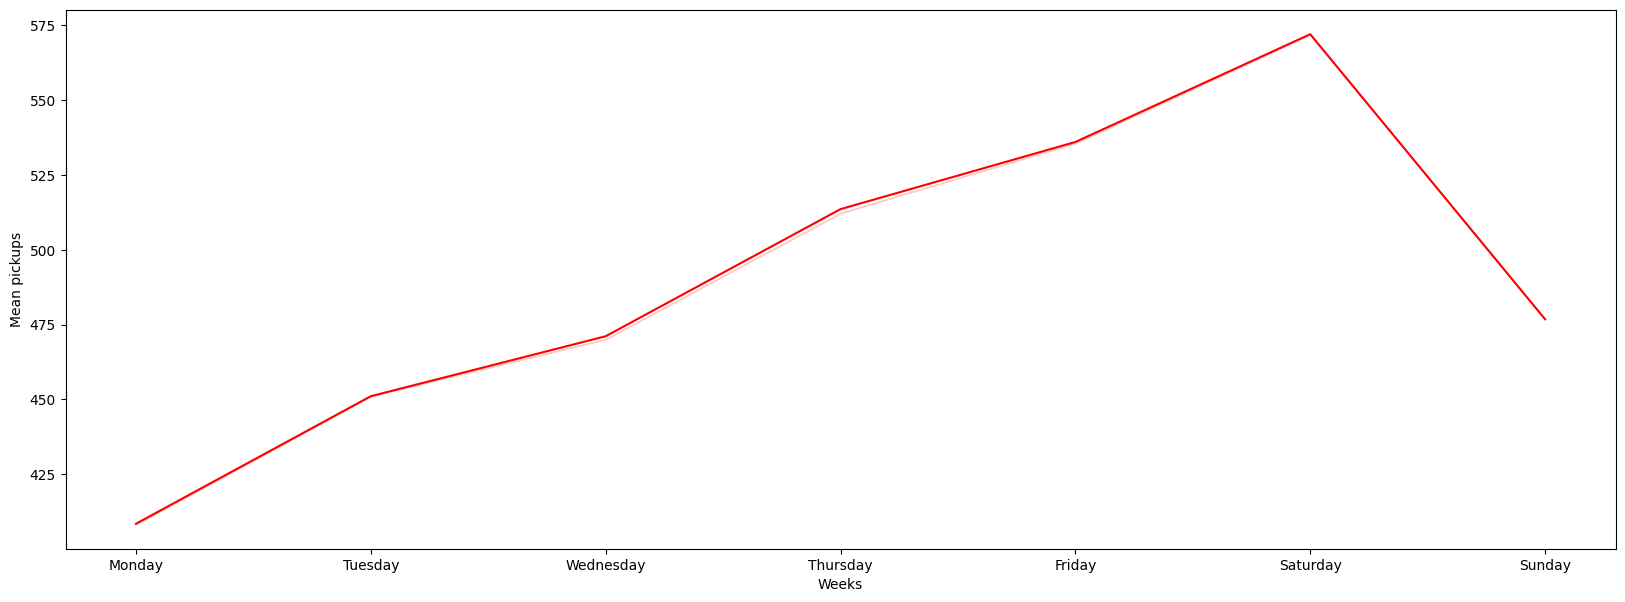

In [ ]:
cats = ['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday']
df.week_day = pd.Categorical(df.week_day, ordered = True, categories = cats)
plt.figure(figsize = (20, 7))
sns.lineplot(x = "week_day", y = "pickups", ci = 0, data = df, color = "RED")
plt.ylabel('Mean pickups')
plt.xlabel('Weeks')
plt.show()

**Observations:**
* Pickups gradually increase as the week progresses and starts dropping after Saturday.
* We need to do more investigation to understand why the demand for Uber is low at the beginning of the week.

### **Pickups across Boroughs**

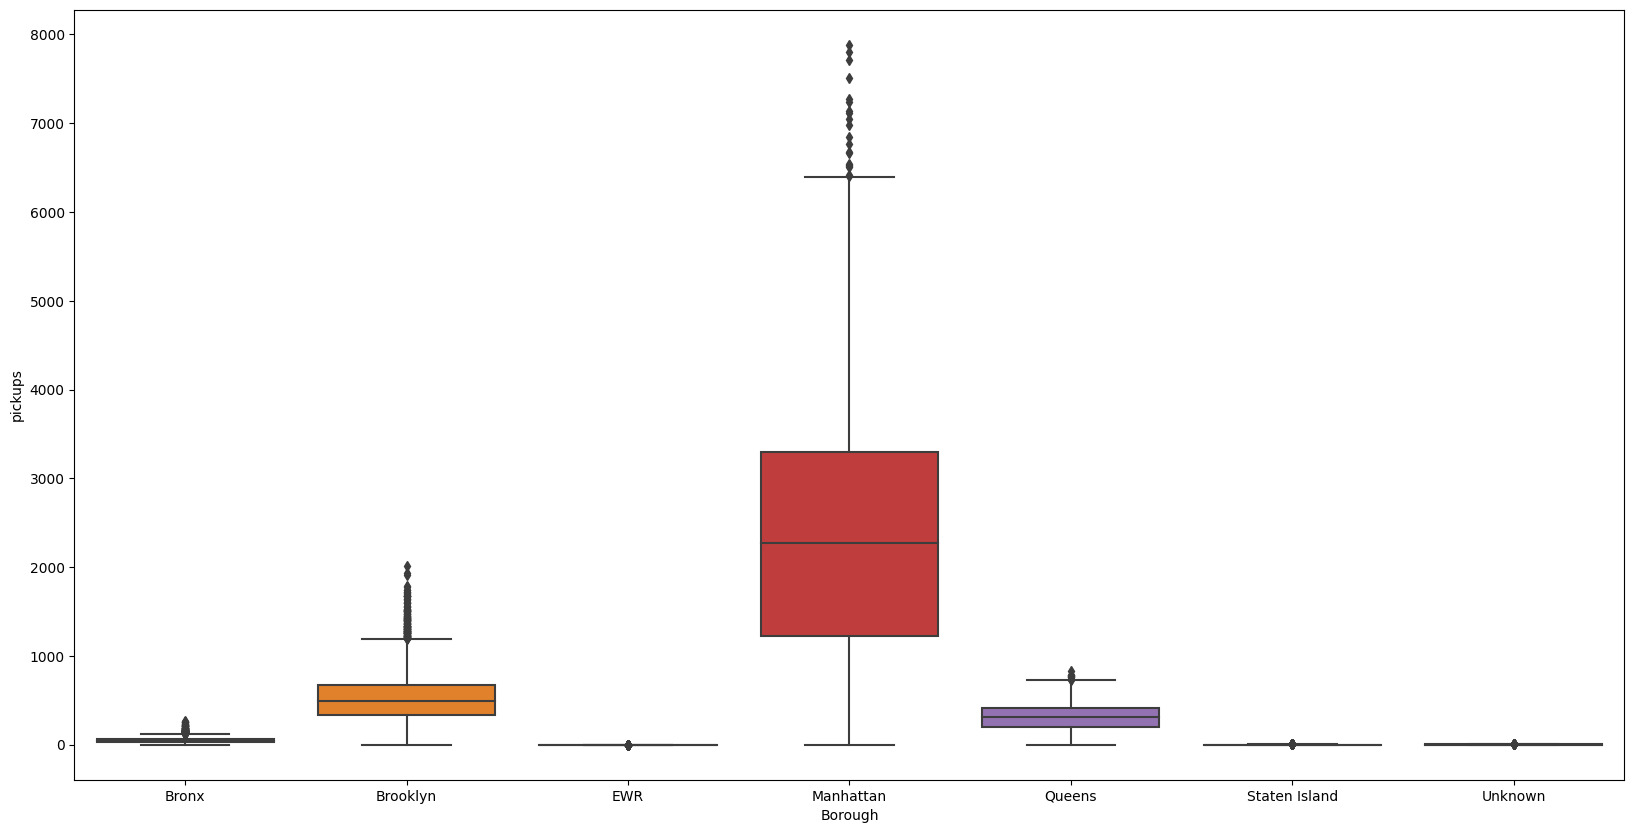

In [ ]:
plt.figure(figsize = (20, 10))
sns.boxplot(x='borough', y='pickups', data=df)
plt.ylabel('pickups')
plt.xlabel('Borough')
plt.show()

**Observations:**
* There is a clear difference in ridership across the different boroughs.
* Manhattan has the highest number of bookings.
* Brooklyn and Queens are distant followers.
* EWR, Unknown, and Staten Island have a very low number of bookings. The demand is so small that probably it can be covered by the drop-offs of the inbound trips from other areas.

### **Relationship between Pickups and Holidays**

In [ ]:
df.groupby('hday')['pickups'].mean()

hday
N    492.339957
Y    437.199822
Name: pickups, dtype: float64

In [ ]:
# Check if the trend is similar across boroughs
df.groupby(by = ['borough','hday'])['pickups'].mean()

borough        hday
Bronx          N         50.771073
               Y         48.065868
Brooklyn       N        534.727969
               Y        527.011976
EWR            N          0.023467
               Y          0.041916
Manhattan      N       2401.302921
               Y       2035.928144
Queens         N        308.899904
               Y        320.730539
Staten Island  N          1.606082
               Y          1.497006
Unknown        N          2.057456
               Y          2.050420
Name: pickups, dtype: float64

**Observations:**
1. The mean pickups on holidays are lesser than a non-holiday.
2. Except for Manhattan, mean pickups on holidays are pretty similar to non-holiday pickups.
3. In Queens, mean pickups on holidays are higher.
4. There are hardly any pickups in EWR.

### **Relationship between Pickups and Hour of the day across Boroughs**

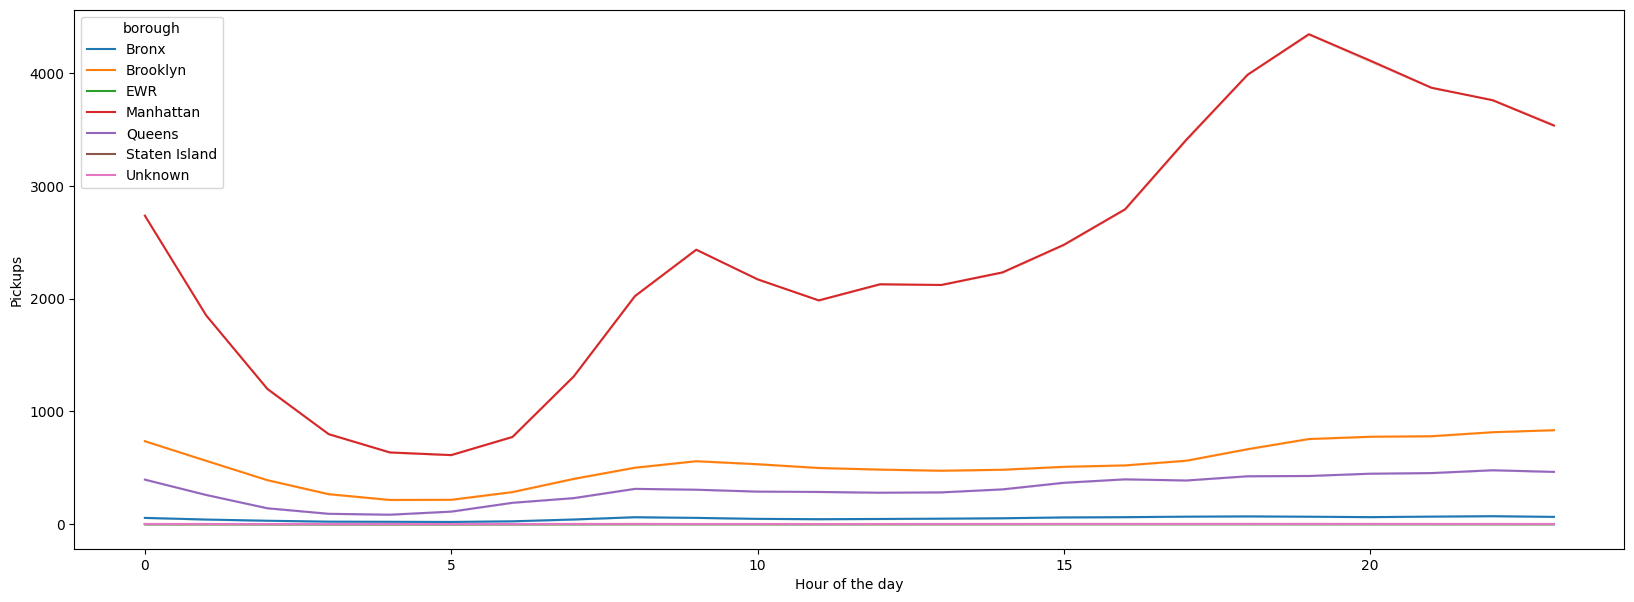

In [ ]:
plt.figure(figsize = (20, 7))
sns.lineplot(x = "start_hour", y = "pickups", ci = 0, data = df, hue = 'borough')
plt.ylabel('Pickups')
plt.xlabel('Hour of the day')
plt.show()

**Observations:**

* Bookings peak around the 19th and 20th hour of the day and decreases till 5 AM.
* The peak can be attributed to the time people leave their workplaces.
* From 5 AM onwards, we can see an increasing trend till 10, possibly the office rush.
* Pickups go down from 10 AM to 12 PM post that they start increasing.
* The number of pickups in Manhattan is very high and dominant when we see the spread across boroughs.
* We cannot observe the distribution for EWR and Staten Island boroughs in this plot due to the very low count in these boroughs. Let's try converting the pickups on a logarithmic scale to visualize all the boroughs.

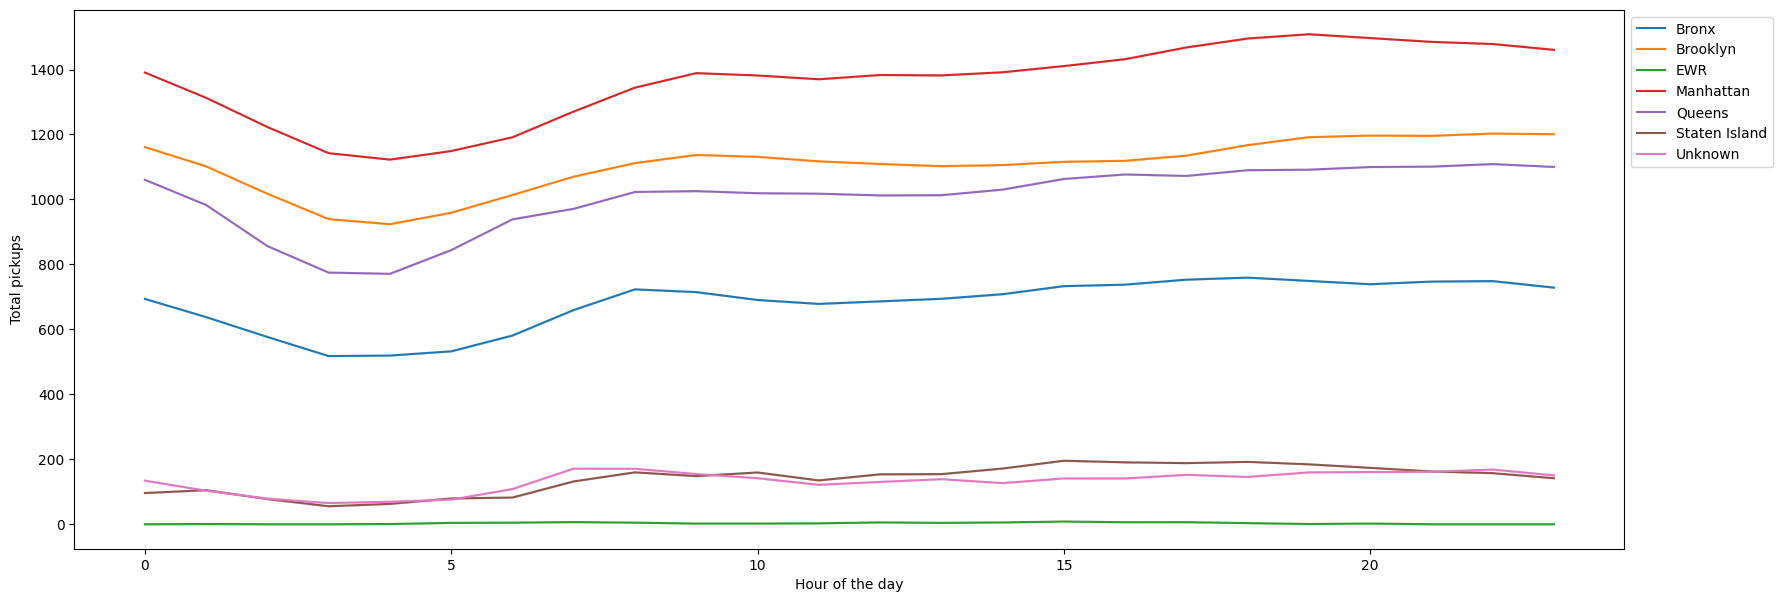

In [ ]:
plt.figure(figsize = (20, 7))
sns.lineplot(x = df.start_hour, y = np.log1p(df.pickups), estimator ='sum', ci = 0, hue = df.borough)
plt.ylabel('Total pickups')
plt.xlabel('Hour of the day')
plt.legend(bbox_to_anchor = (1, 1))
plt.show()

**Observations:**
* Hourly pattern can be seen in almost all the boroughs.
* After applying the logarithmic scale, it is obvious that the four major boroughs follow the same pattern.
* EWR seems to have a random demand with a majority of the values being zero.
* Manhattan sees the most Uber pickups. Let us explore this borough in more detail.

### Manhattan Pickups Heatmap - Weekday vs Hour

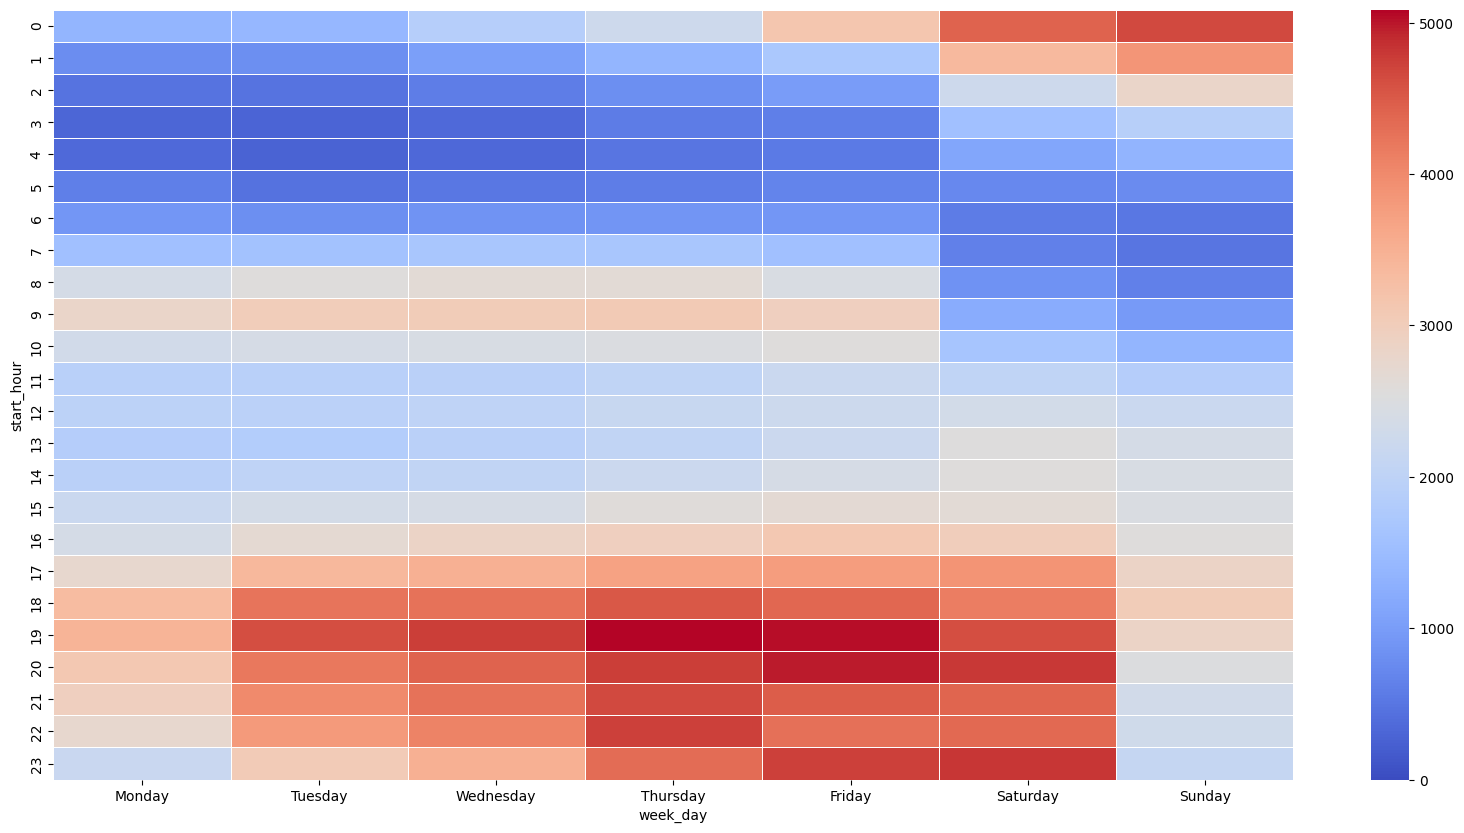

In [ ]:
df_man = df[df.borough == 'Manhattan']
df_hm = df_man.pivot_table(index = 'start_hour', columns = 'week_day', values = 'pickups')

# Draw a heatmap
plt.figure(figsize = (20, 10)) # To resize the plot
sns.heatmap(df_hm,  fmt = "d", cmap = 'coolwarm', linewidths = .5, vmin = 0)
plt.show()
#Larger number of Ubers are used between Tuesday to Saturday in Manhattan
#between 4pm to 12 am between Tuesday to Sunday, maximum pickups are done
#so Uber needs to be prepared during that time in Manhattan

**Observations:**

* The demand for Uber peaks during the late hours of the day when people are returning home from the office.
* Demand continues to be high during the late hours of the day (midnight) on Fridays and Saturdays.  
* It is odd that the demand for Uber is not as high on Monday evenings in comparison to other working days.